# Transfer learning comparison

Validation reward comparison between the v11.11.1 baseline, pretrained encoders, and original encoders trained from scratch.

In [7]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import FancyBboxPatch
from tensorboard.backend.event_processing.event_accumulator import EventAccumulator


CURRENT_DIR = Path.cwd().resolve()
PROJECT_ROOT = CURRENT_DIR.parent if CURRENT_DIR.name == "statistic" else CURRENT_DIR
LOGS2_ROOT = PROJECT_ROOT / "logs2"
LOGS3_ROOT = PROJECT_ROOT / "logs3"
TAG = "Reward/validation"
TOTAL_EPISODES = 10_000
VARIANT = 0


def read_validation_series(run_path: Path, max_step: int = TOTAL_EPISODES):
    if not run_path.exists():
        raise FileNotFoundError(f"Missing log directory: {run_path}")

    event_files = list(run_path.glob("events.out.tfevents*"))
    if not event_files:
        raise FileNotFoundError(f"No TensorBoard event file found in: {run_path}")

    accumulator = EventAccumulator(str(run_path), size_guidance={"scalars": 0})
    accumulator.Reload()
    scalar_tags = accumulator.Tags().get("scalars", [])
    if TAG not in scalar_tags:
        raise KeyError(f"{TAG!r} is not available in {run_path}; tags: {scalar_tags}")

    series = [
        (point.step, point.value)
        for point in accumulator.Scalars(TAG)
        if point.step <= max_step
    ]
    if not series:
        raise ValueError(f"No validation points at or below episode {max_step}: {run_path}")
    return series


def load_runs(run_definitions):
    curves = []
    missing = []

    for run in run_definitions:
        try:
            series = read_validation_series(run["path"])
        except Exception as exc:
            missing.append((run["label"], run["path"], exc))
            continue

        best_step, best_reward = max(series, key=lambda point: point[1])
        curves.append(
            {**run, "series": series, "best_step": best_step, "best_reward": best_reward}
        )

    return curves, missing


def print_summary(curves, missing):
    for curve in curves:
        print(
            f"{curve['label']}: {len(curve['series'])} validation points, "
            f"best reward = {curve['best_reward']:.2f} at episode {curve['best_step']}"
        )

    if missing:
        print("\nRuns waiting for TensorBoard logs:")
        for label, path, exc in missing:
            print(f"- {label}: {path} ({exc})")


def plot_transfer_learning(curves):
    if not curves:
        raise RuntimeError("No validation curves could be loaded.")

    fig = plt.figure(figsize=(20.0, 6.4), dpi=140)
    ax = fig.add_axes([0.08, 0.13, 0.58, 0.82])
    legend_ax = fig.add_axes([0.67, 0.13, 0.32, 0.82])
    legend_ax.axis("off")

    for curve in curves:
        steps = [step for step, _ in curve["series"]]
        rewards = [reward for _, reward in curve["series"]]
        ax.plot(
            steps,
            rewards,
            color=curve["color"],
            linestyle=curve["linestyle"],
            linewidth=2.2,
            label=curve["label"],
        )

    legend_top = 0.97
    row_gap = 0.095
    box_height = row_gap * len(curves) + 0.055
    legend_box = FancyBboxPatch(
        (0.0, legend_top - box_height + 0.025),
        0.98,
        box_height,
        boxstyle="round,pad=0.012",
        facecolor="white",
        edgecolor="0.8",
        transform=legend_ax.transAxes,
        clip_on=False,
    )
    legend_ax.add_patch(legend_box)

    for index, curve in enumerate(curves):
        y = legend_top - 0.025 - row_gap * index
        legend_ax.plot(
            [0.04, 0.17],
            [y, y],
            color=curve["color"],
            linestyle=curve["linestyle"],
            linewidth=2.8,
            transform=legend_ax.transAxes,
            clip_on=False,
        )
        legend_ax.text(
            0.21, y, curve["label"], transform=legend_ax.transAxes,
            ha="left", va="center", fontsize=10,
        )
        legend_ax.text(
            0.61, y, f"Best Validation Reward: {curve['best_reward']:.2f}",
            transform=legend_ax.transAxes, ha="left", va="center", fontsize=10,
        )

    info_y = legend_top - box_height - 0.035
    info_lines = [
        f"Variant: {VARIANT}",
        f"Total Episodes: {TOTAL_EPISODES // 1000}k",
        "DRL Policy: Rainbow DQN",
    ]
    for index, line in enumerate(info_lines):
        legend_ax.text(
            0.04, info_y - 0.085 * index, line, transform=legend_ax.transAxes,
            ha="left", va="top", fontsize=10,
        )

    reward_max = max(reward for curve in curves for _, reward in curve["series"])
    ax.set_xlim(0, TOTAL_EPISODES)
    ax.set_ylim(0, np.ceil((reward_max + 5) / 10) * 10)
    ax.set_xticks(range(0, TOTAL_EPISODES + 1, 1000))
    ax.set_xlabel("Training Episode", labelpad=10)
    ax.set_ylabel("Average Validation Reward", labelpad=12)
    ax.grid(axis="x", linestyle="--", alpha=0.28)
    ax.grid(axis="y", linestyle="-", alpha=0.18)

    return fig, ax


print(f"Project root: {PROJECT_ROOT}")

Project root: /Users/zlr/Documents/CodingLab：DRL/CodingLab_DRL_team


In [8]:
RUNS = [
    {
        "label": "Baseline",
        "path": LOGS3_ROOT / "DQN_v11.11.1_variant_0",
        "color": "tab:blue",
        "linestyle": "-",
    },
    {
        "label": "Pretrain ResNet18",
        "path": LOGS3_ROOT / "DQN_v11.11.11_variant_0",
        "color": "tab:green",
        "linestyle": "-",
    },
    {
        "label": "Pretrain AlexNet",
        "path": LOGS3_ROOT / "DQN_v11.11.12_variant_0",
        "color": "tab:orange",
        "linestyle": "-",
    },
    {
        "label": "Pretrain LeNet",
        "path": LOGS3_ROOT / "DQN_v11.11.13_variant_0",
        "color": "tab:purple",
        "linestyle": "-",
    },
    {
        "label": "Original ResNet18",
        "path": LOGS2_ROOT / "DQN_v11.11.14_variant_0",
        "color": "tab:green",
        "linestyle": "--",
    },
    {
        "label": "Original AlexNet",
        "path": LOGS2_ROOT / "DQN_v11.11.15_variant_0",
        "color": "tab:orange",
        "linestyle": "--",
    },
    {
        "label": "Original LeNet",
        "path": LOGS2_ROOT / "DQN_v11.11.16_variant_0",
        "color": "tab:purple",
        "linestyle": "--",
    },
]

Baseline: 100 validation points, best reward = 223.04 at episode 8800
Pretrain ResNet18: 100 validation points, best reward = 222.47 at episode 6300
Pretrain AlexNet: 100 validation points, best reward = 223.26 at episode 7200
Pretrain LeNet: 100 validation points, best reward = 214.73 at episode 9400
Original ResNet18: 100 validation points, best reward = 188.54 at episode 8200
Original AlexNet: 100 validation points, best reward = 213.43 at episode 7800
Original LeNet: 100 validation points, best reward = 202.01 at episode 8700


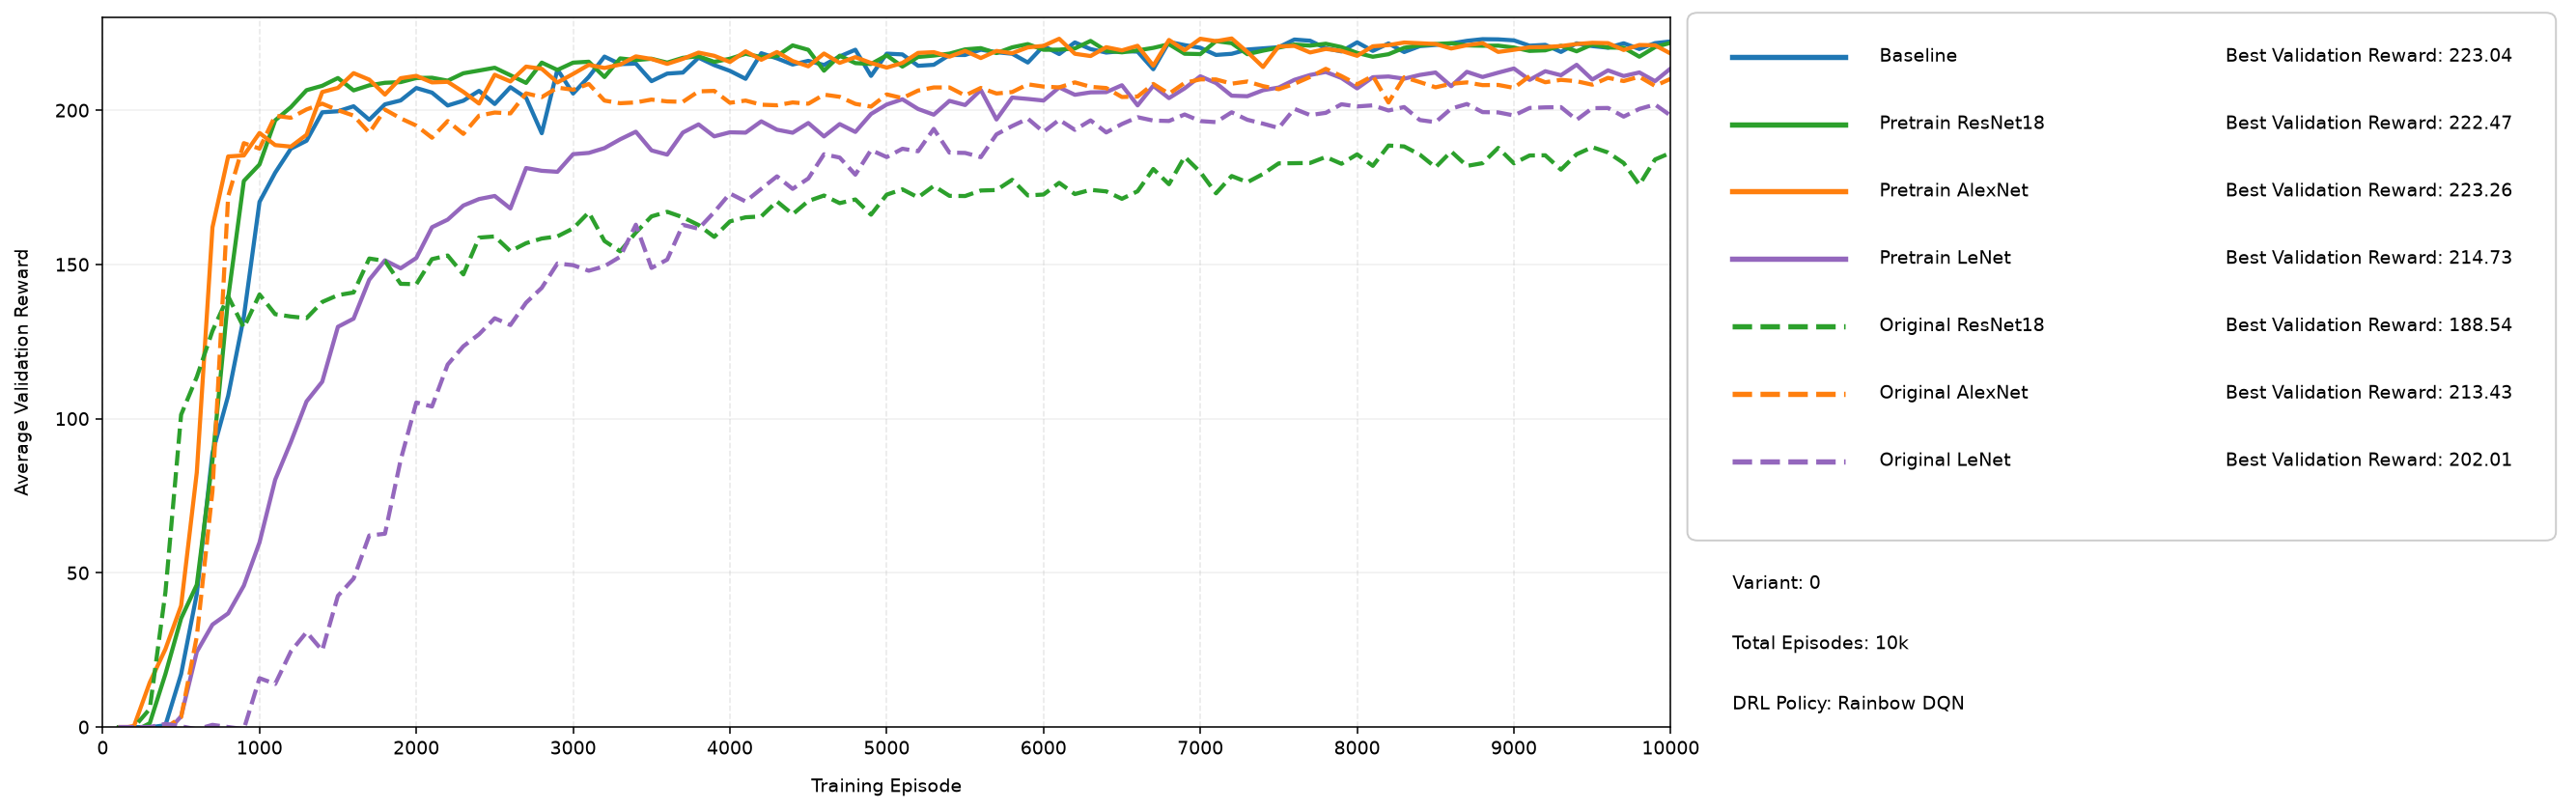

In [9]:
curves, missing_runs = load_runs(RUNS)
print_summary(curves, missing_runs)
transfer_learning_fig, transfer_learning_ax = plot_transfer_learning(curves)
plt.show()